# 📡 Notebook 1: Download NO₂ Satellite Data

## Purpose
Downloads TROPOMI NO₂ data from Google Earth Engine for Delhi, India.
Produces both an annual mean map and 12 monthly maps for 2023.

## Outputs
- `data/raw/delhi_no2_2023.tif` — annual mean NO₂
- `data/raw/delhi_no2_2023_jan.tif` through `_dec.tif` — monthly maps

## Requirements
- Google Earth Engine account (project: teak-catwalk-473711-r3)
- `earthengine-api` library installed

In [1]:
# Step 1: Import and authenticate Google Earth Engine
import ee 

# This will open a browser window asking you to log in with your Google Account
ee.Authenticate()

# Initialize GEE
ee.Initialize(project='teak-catwalk-473711-r3')

c:\Users\USER\anaconda3\envs\airquality\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# Define Delhi's boundary (bounding box)
delhi = ee.Geometry.Rectangle([76.8, 28.4, 77.4, 28.9])

# Load TROPOMI NO2 data for year 2023
no2_collection = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2') \
    .filterDate('2023-01-01', '2023-12-31') \
    .filterBounds(delhi) \
    .select('NO2_column_number_density')

# Calculate annual mean
no2_mean = no2_collection.mean().clip(delhi)

print("✅ NO2 data loaded successfully!")
print(f"Number of images: {no2_collection.size().getInfo()}")

✅ NO2 data loaded successfully!
Number of images: 987


In [3]:
# Export to your Google Drive
task = ee.batch.Export.image.toDrive(
    image=no2_mean,
    description='Delhi_NO2_2023_mean',
    folder='airquality_data',        # folder name in your Google Drive
    fileNamePrefix='delhi_no2_2023',
    region=delhi,
    scale=1000,                      # 1km resolution
    crs='EPSG:4326',
    fileFormat='GeoTIFF'
)

task.start()
print("✅ Export started! Check Google Drive in a few minutes.")
print(f"Task status: {task.status()}")

✅ Export started! Check Google Drive in a few minutes.
Task status: {'state': 'READY', 'description': 'Delhi_NO2_2023_mean', 'priority': 100, 'creation_timestamp_ms': 1775128491024, 'update_timestamp_ms': 1775128491024, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'SF4NW4WQKSXQFW72SRORWGVU', 'name': 'projects/teak-catwalk-473711-r3/operations/SF4NW4WQKSXQFW72SRORWGVU'}


Current folder: c:\Users\USER\Projects\Downscaling-of-satellite-based-air-quality-map


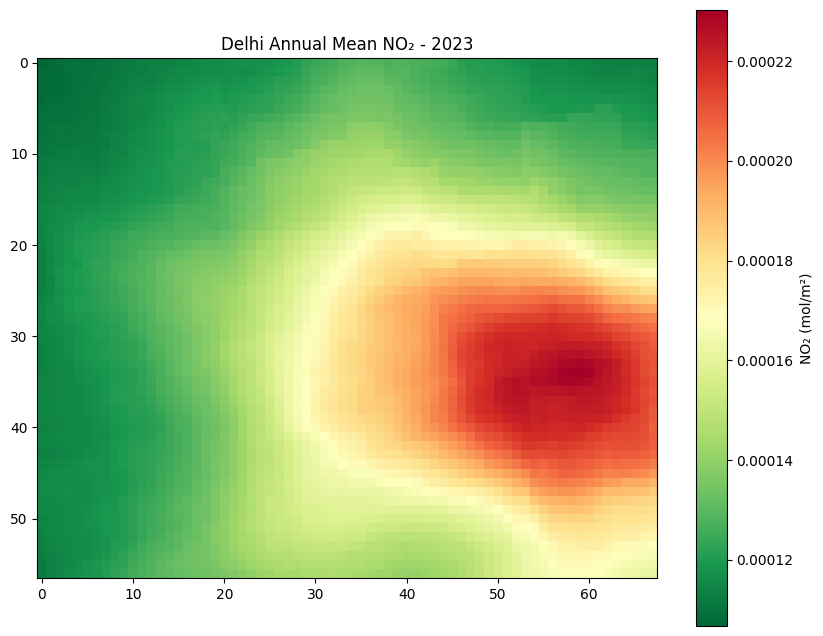

Data shape: (57, 68)
Min NO₂: 0.000107
Max NO₂: 0.000230
Mean NO₂: 0.000151


In [4]:
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Navigate to project root folder
os.chdir('..')
print("Current folder:", os.getcwd())

# Load the downloaded NO2 data
with rasterio.open('data/raw/delhi_no2_2023.tif') as src:
    no2_data = src.read(1)
    profile = src.profile
    bounds = src.bounds

# Replace negative/invalid values with NaN
no2_data = np.where(no2_data < 0, np.nan, no2_data)

# Plot it
plt.figure(figsize=(10, 8))
plt.imshow(no2_data, cmap='RdYlGn_r')
plt.colorbar(label='NO₂ (mol/m²)')
plt.title('Delhi Annual Mean NO₂ - 2023')
plt.savefig('outputs/delhi_no2_map.png', dpi=300)
plt.show()

# Print basic info
print(f"Data shape: {no2_data.shape}")
print(f"Min NO₂: {np.nanmin(no2_data):.6f}")
print(f"Max NO₂: {np.nanmax(no2_data):.6f}")
print(f"Mean NO₂: {np.nanmean(no2_data):.6f}")

In [5]:
import ee
import os

ee.Initialize(project='teak-catwalk-473711-r3')

delhi = ee.Geometry.Rectangle([76.8, 28.4, 77.4, 28.9])

# Download one image per month
months = [
    ('2023-01-01', '2023-02-01', 'jan'),
    ('2023-02-01', '2023-03-01', 'feb'),
    ('2023-03-01', '2023-04-01', 'mar'),
    ('2023-04-01', '2023-05-01', 'apr'),
    ('2023-05-01', '2023-06-01', 'may'),
    ('2023-06-01', '2023-07-01', 'jun'),
    ('2023-07-01', '2023-08-01', 'jul'),
    ('2023-08-01', '2023-09-01', 'aug'),
    ('2023-09-01', '2023-10-01', 'sep'),
    ('2023-10-01', '2023-11-01', 'oct'),
    ('2023-11-01', '2023-12-01', 'nov'),
    ('2023-12-01', '2024-01-01', 'dec'),
]

tasks = []
for start, end, month_name in months:
    # Get monthly mean NO₂
    monthly_no2 = ee.ImageCollection(
        'COPERNICUS/S5P/NRTI/L3_NO2'
    ) \
    .filterDate(start, end) \
    .filterBounds(delhi) \
    .select('NO2_column_number_density') \
    .mean() \
    .clip(delhi)
    
    # Export each month separately
    task = ee.batch.Export.image.toDrive(
        image=monthly_no2,
        description=f'Delhi_NO2_2023_{month_name}',
        folder='airquality_data',
        fileNamePrefix=f'delhi_no2_2023_{month_name}',
        region=delhi,
        scale=1000,
        crs='EPSG:4326',
        fileFormat='GeoTIFF'
    )
    task.start()
    tasks.append((month_name, task))
    print(f"✅ Export started: {month_name}")

print(f"\nTotal tasks started: {len(tasks)}")
print("Check Google Drive in 10-15 minutes!")

✅ Export started: jan
✅ Export started: feb
✅ Export started: mar
✅ Export started: apr
✅ Export started: may
✅ Export started: jun
✅ Export started: jul
✅ Export started: aug
✅ Export started: sep
✅ Export started: oct
✅ Export started: nov
✅ Export started: dec

Total tasks started: 12
Check Google Drive in 10-15 minutes!
